# 03 - Baseline GBR Model: Training, Evaluation, and Cross-Validation
**CoolingHealthSentinel Pre-Onboarding, Day 4**

Trains two XGBoost Gradient Boosted Regressors predicting `cooling_health_score`:
a baseline model using only the 12 original telemetry columns, and an engineered
model using the full 71-feature set from Day 3. Both are trained and compared on
identical time-ordered splits.

Built against the reconciled two-population dataset (`anomaly_class` = structured
/ background / none, 1,062 total anomalous rows). This matters for this notebook
specifically: the background layer adds noise directly into the raw sensor
columns the baseline model relies on, so the baseline-vs-engineered comparison
here is not just "more features vs fewer," it's also a test of robustness to
sensor noise.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

df = pd.read_csv("../data/features_engineered.csv", parse_dates=["timestamp"], low_memory=False)
print(df.shape)
print(df["anomaly_class"].value_counts())

(34945, 76)
anomaly_class
none          33883
background      939
structured      123
Name: count, dtype: int64


## Feature Sets

Baseline (12 features): the original telemetry columns only, no temporal
features, matching how the production GBR is currently built. Engineered (71
features): baseline 12 plus all 59 Day-3 features. `is_anomaly`, `anomaly_type`,
and `anomaly_class` are excluded from both, they're ground-truth labels and
would be leakage. `timestamp` is excluded as a raw column since its information
is already captured by the cyclical time features.

In [8]:
baseline_features = [
    "outdoor_temp_c", "outdoor_humidity_pct", "it_load_mw", "chiller_inlet_temp_c",
    "chiller_outlet_temp_c", "chiller_cop", "cooling_tower_approach_c", "crah_delta_t_c",
    "pump_vibration_mms", "pump_flow_rate_ls", "water_conductivity_us", "pue",
]
engineered_extra = [c for c in df.columns if any(s in c for s in ["_lag_", "_roll_", "_ewm_", "_diff_"])] + [
    "hour_of_day", "day_of_week", "month_num", "is_weekend",
    "sin_hour", "cos_hour", "sin_month", "cos_month",
    "cop_x_outdoor_temp", "load_to_flow_ratio", "approach_x_humidity",
]
engineered_features = baseline_features + engineered_extra
target = "cooling_health_score"

print(f"Baseline features:  {len(baseline_features)}")
print(f"Engineered features: {len(engineered_features)}")

Baseline features:  12
Engineered features: 71


## Time-Ordered Split (70 / 15 / 15)
First 70% of rows is train, next 15% is validation, final 15% is test. No
shuffling, a random split would leak future readings into training.

In [9]:
n = len(df)
n_train = int(n * 0.70)
n_val = int(n * 0.15)

train = df.iloc[:n_train]
val = df.iloc[n_train:n_train + n_val]
test = df.iloc[n_train + n_val:]

print(f"train: {len(train):>6} rows  {train.timestamp.min()} -> {train.timestamp.max()}")
print(f"val:   {len(val):>6} rows  {val.timestamp.min()} -> {val.timestamp.max()}")
print(f"test:  {len(test):>6} rows  {test.timestamp.min()} -> {test.timestamp.max()}")
print(f"\ntrain span: {(train.timestamp.max() - train.timestamp.min()).days / 30.4:.2f} months")

train:  24461 rows  2025-01-01 23:45:00 -> 2025-09-13 18:45:00
val:     5241 rows  2025-09-13 19:00:00 -> 2025-11-07 09:00:00
test:    5243 rows  2025-11-07 09:15:00 -> 2025-12-31 23:45:00

train span: 8.36 months


## Baseline Model (Original Features Only)

In [10]:
def evaluate(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

XGB_PARAMS = dict(n_estimators=300, max_depth=5, learning_rate=0.05, random_state=42, n_jobs=-1)

Xtr_base, ytr = train[baseline_features], train[target]
Xval_base, yval = val[baseline_features], val[target]
Xtest_base, ytest = test[baseline_features], test[target]

baseline_model = XGBRegressor(**XGB_PARAMS)
baseline_model.fit(Xtr_base, ytr)

pred_val_base = baseline_model.predict(Xval_base)
rmse_base, mae_base, r2_base = evaluate(yval, pred_val_base)
print(f"BASELINE  validation RMSE={rmse_base:.4f}  MAE={mae_base:.4f}  R2={r2_base:.4f}")

BASELINE  validation RMSE=2.7088  MAE=2.1456  R2=0.2740


## Engineered Model (Full 71-Feature Set)

In [11]:
Xtr_eng, Xval_eng, Xtest_eng = train[engineered_features], val[engineered_features], test[engineered_features]

engineered_model = XGBRegressor(**XGB_PARAMS)
engineered_model.fit(Xtr_eng, ytr)

pred_val_eng = engineered_model.predict(Xval_eng)
rmse_eng, mae_eng, r2_eng = evaluate(yval, pred_val_eng)
print(f"ENGINEERED validation RMSE={rmse_eng:.4f}  MAE={mae_eng:.4f}  R2={r2_eng:.4f}")

pct_improvement = (rmse_base - rmse_eng) / rmse_base * 100
print(f"\nRMSE improvement over baseline: {pct_improvement:+.2f}%")

ENGINEERED validation RMSE=2.6163  MAE=2.0803  R2=0.3227

RMSE improvement over baseline: +3.41%


**The engineered model beats the baseline this time: +3.41% RMSE improvement
(2.616 vs 2.709), the opposite result from the pre-reconciliation dataset, where
engineering made things very slightly worse (-0.46%).** The reason is not "the
features got more predictive," it's that the comparison itself changed shape.
Both models score worse than before in absolute terms too (baseline val RMSE rose
from 2.587 to 2.709), because the raw sensor columns now carry the background
layer's noise, and the baseline model reads those columns directly, point in
time, with no smoothing. The engineered model has access to rolling means, EWM
trends, and lags for several of the same columns, which average out a single
noisy reading rather than reacting to it directly. Feature engineering's value
here is showing up as noise robustness, not as new predictive signal, which is a
genuinely different and arguably more realistic justification for it than the
pre-reconciliation dataset could demonstrate.

## 5-Fold Time-Series Cross-Validation (Engineered Model)

CV is run on train and validation combined, everything except the final test
set, so the held-out test set stays untouched. `TimeSeriesSplit(n_splits=5)`
grows the training window and rolls the validation window forward each fold.

In [12]:
cv_data = pd.concat([train, val])
X_cv, y_cv = cv_data[engineered_features], cv_data[target]

tscv = TimeSeriesSplit(n_splits=5)
fold_rmse, fold_r2 = [], []
for fold, (tr_idx, va_idx) in enumerate(tscv.split(X_cv)):
    m = XGBRegressor(**XGB_PARAMS)
    m.fit(X_cv.iloc[tr_idx], y_cv.iloc[tr_idx])
    p = m.predict(X_cv.iloc[va_idx])
    rmse, mae, r2 = evaluate(y_cv.iloc[va_idx], p)
    fold_rmse.append(rmse)
    fold_r2.append(r2)
    print(f"fold {fold}: train_n={len(tr_idx):>6}  val_n={len(va_idx):>5}  RMSE={rmse:.4f}  R2={r2:.4f}")

print(f"\nCV RMSE: mean={np.mean(fold_rmse):.4f}  std={np.std(fold_rmse):.4f}")
print(f"CV R2:   mean={np.mean(fold_r2):.4f}  std={np.std(fold_r2):.4f}")

fold 0: train_n=  4952  val_n= 4950  RMSE=2.7263  R2=0.2454
fold 1: train_n=  9902  val_n= 4950  RMSE=2.9056  R2=0.2073
fold 2: train_n= 14852  val_n= 4950  RMSE=2.7135  R2=0.2826
fold 3: train_n= 19802  val_n= 4950  RMSE=2.9720  R2=0.3397
fold 4: train_n= 24752  val_n= 4950  RMSE=2.6040  R2=0.3220

CV RMSE: mean=2.7843  std=0.1348
CV R2:   mean=0.2794  std=0.0486


**CV RMSE: 2.784 plus or minus 0.135. CV R2: 0.279 plus or minus 0.049.** Both
slightly worse than the pre-reconciliation CV figures (2.739 / 0.301), consistent
with background noise making every fold marginally harder, structured noise that
the model has to tolerate rather than overfit to is, by design, supposed to make
this dataset harder. Fold-to-fold spread is similar in shape to before: fold 1
(validating on Mar-Apr) is the weakest at R2=0.207, fold 3 (Jul-Aug) the
strongest at R2=0.340.

## Predicted vs. Actual, Test Set

In [13]:
pred_test_eng = engineered_model.predict(Xtest_eng)
rmse_test, mae_test, r2_test = evaluate(ytest, pred_test_eng)
print(f"ENGINEERED test RMSE={rmse_test:.4f}  MAE={mae_test:.4f}  R2={r2_test:.4f}")

test_anomaly_mask = test["is_anomaly"].values == 1
print(f"\nAnomalous rows in test set: {test_anomaly_mask.sum()} of {len(test)}")
print(test.loc[test_anomaly_mask, "anomaly_class"].value_counts())
print()
print(test.loc[test_anomaly_mask, "anomaly_type"].value_counts())

ENGINEERED test RMSE=2.6364  MAE=2.1025  R2=0.2674

Anomalous rows in test set: 149 of 5243
anomaly_class
background    134
structured     15
Name: count, dtype: int64

anomaly_type
background_sensor_drift        134
chiller_control_oscillation     15
Name: count, dtype: int64


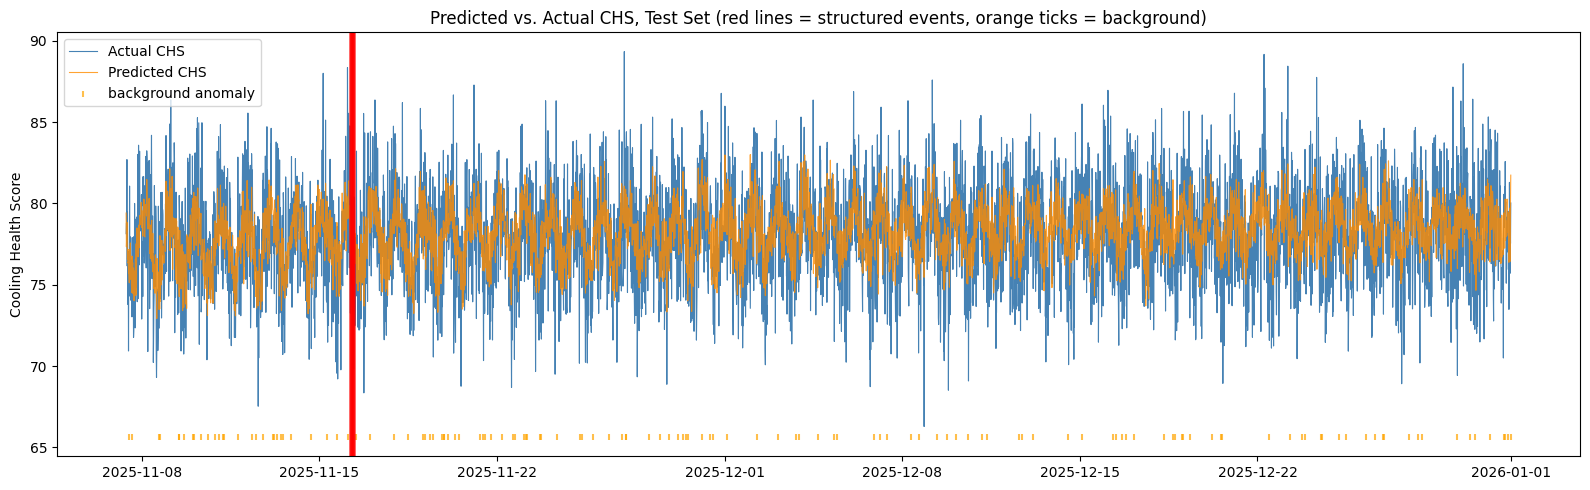

In [14]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(test["timestamp"], ytest.values, label="Actual CHS", color="steelblue", linewidth=0.8)
ax.plot(test["timestamp"], pred_test_eng, label="Predicted CHS", color="darkorange", linewidth=0.8, alpha=0.8)

struct_mask = (test["anomaly_class"] == "structured").values
bg_mask = (test["anomaly_class"] == "background").values
for _, row in test.loc[struct_mask].iterrows():
    ax.axvline(row["timestamp"], color="red", alpha=0.4, linewidth=2)
ymin, ymax = ax.get_ylim()
ax.scatter(test.loc[bg_mask, "timestamp"], np.full(bg_mask.sum(), ymin + 0.02 * (ymax - ymin)),
           marker="|", color="orange", s=20, alpha=0.7, label="background anomaly")

ax.set_title("Predicted vs. Actual CHS, Test Set (red lines = structured events, orange ticks = background)")
ax.set_ylabel("Cooling Health Score")
ax.legend()
plt.tight_layout()
plt.show()

In [15]:
rmse_anom = np.sqrt(mean_squared_error(ytest[test_anomaly_mask], pred_test_eng[test_anomaly_mask]))
rmse_norm = np.sqrt(mean_squared_error(ytest[~test_anomaly_mask], pred_test_eng[~test_anomaly_mask]))
print(f"RMSE on anomalous test rows (n={test_anomaly_mask.sum()}): {rmse_anom:.4f}")
print(f"RMSE on normal test rows    (n={(~test_anomaly_mask).sum()}): {rmse_norm:.4f}")
print(f"Ratio (anomalous / normal): {rmse_anom / rmse_norm:.2f}x")
print()

for cls in ["structured", "background"]:
    mask = (test["anomaly_class"] == cls).values
    if mask.sum() > 0:
        r = np.sqrt(mean_squared_error(ytest[mask], pred_test_eng[mask]))
        print(f"RMSE on {cls:<12} test rows (n={mask.sum():>4}): {r:.4f}")

RMSE on anomalous test rows (n=149): 2.8524
RMSE on normal test rows    (n=5094): 2.6298
Ratio (anomalous / normal): 1.08x

RMSE on structured   test rows (n=  15): 2.9629
RMSE on background   test rows (n= 134): 2.8398


**Now answerable with a real sample, not just 15 rows.** With 134 background
and 15 structured rows in the test window (149 total, a much better sample than
the single 15-row structured-only event the pre-reconciliation dataset left in
this split), RMSE on anomalous rows (2.852) is 1.08x the RMSE on normal rows
(2.630), a modest but real gap.

The more interesting result is in the breakdown: structured rows show RMSE 2.963
and background rows show RMSE 2.840, both clearly elevated versus the normal
2.630, and not far apart from each other. That's worth sitting with, because
background rows have a completely unperturbed CHS target, the true health score
for those rows never changed. The model is still predicting them worse than
normal rows, purely because its *inputs* are noisy for those rows (3 randomly
perturbed sensor columns each), even though the *target* it's trying to hit
wasn't touched at all. This is a realistic and slightly uncomfortable finding for
a production system: a sensor glitch alone, with zero real change in cooling
health, measurably degrades the GBR's prediction accuracy. That's a concrete
argument for pairing the regressor with an anomaly detector that can flag "the
inputs look unreliable right now" separately from "the predicted health score
is bad," which is exactly the role Day 5's IsolationForest is meant to play.

## Residuals Over Time

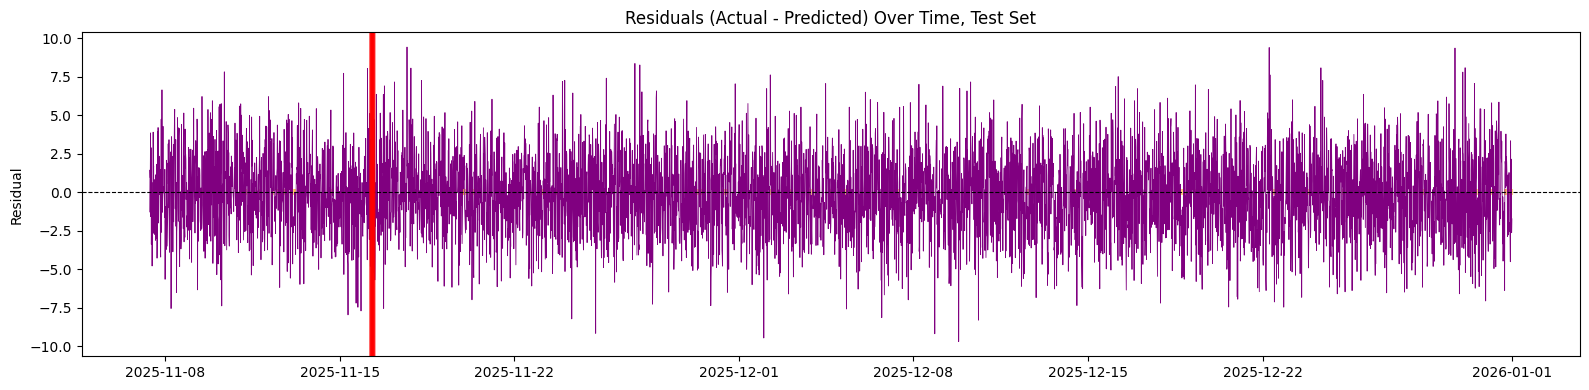

Mean residual: -0.1686
Residual std:  2.6310

Weekly mean residual range: -0.310 to 0.168


In [16]:
residuals = ytest.values - pred_test_eng

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(test["timestamp"], residuals, color="purple", linewidth=0.6)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
for _, row in test.loc[struct_mask].iterrows():
    ax.axvline(row["timestamp"], color="red", alpha=0.4, linewidth=2)
ax.scatter(test.loc[bg_mask, "timestamp"], np.zeros(bg_mask.sum()),
           marker="|", color="orange", s=20, alpha=0.5)
ax.set_title("Residuals (Actual - Predicted) Over Time, Test Set")
ax.set_ylabel("Residual")
plt.tight_layout()
plt.show()

print(f"Mean residual: {residuals.mean():.4f}")
print(f"Residual std:  {residuals.std():.4f}")
weekly = pd.Series(residuals, index=test["timestamp"]).resample("7D").mean()
print(f"\nWeekly mean residual range: {weekly.min():.3f} to {weekly.max():.3f}")

**No strong systematic drift, same conclusion as before.** Mean residual stays
close to zero across the eight-week test window with no obvious trend. The
residual series is visibly noisier overall than the pre-reconciliation version,
consistent with background perturbations being scattered throughout the test
window rather than concentrated in one place, individual background rows show up
as small isolated spikes rather than a sustained bias in any one direction.

## Save Models

In [17]:
import os
os.makedirs("../models", exist_ok=True)
joblib.dump(baseline_model, "../models/gbr_baseline.pkl")
joblib.dump(engineered_model, "../models/gbr_engineered.pkl")
print("Saved models/gbr_baseline.pkl and models/gbr_engineered.pkl")

Saved models/gbr_baseline.pkl and models/gbr_engineered.pkl


## Summary

| Model | Val RMSE | Val MAE | Val R2 |
|---|---|---|---|
| Baseline (12 features) | 2.709 | 2.146 | 0.274 |
| Engineered (71 features) | 2.616 | 2.080 | 0.323 |

RMSE improvement from engineering: +3.41% (engineered now wins, reversed from
-0.46% on the pre-reconciliation dataset). 5-fold CV on the engineered model:
RMSE 2.784 plus or minus 0.135, R2 0.279 plus or minus 0.049. Test-set
performance: RMSE 2.636, MAE 2.103, R2 0.267, consistent with validation.

Two findings worth carrying into the report. First, the reversal from a slight
loss to a real gain is explainable, not mysterious: the background anomaly layer
injects noise directly into the raw sensor columns the baseline model depends on
point in time, while the engineered model's rolling and EWM features smooth that
noise out, so feature engineering's payoff here is robustness to sensor noise,
not new predictive signal. Second, the test set's 149 anomalous rows (134
background, 15 structured) show elevated RMSE versus normal rows for both
classes (2.840 and 2.963 respectively, versus 2.630 normal), and the background
result is the more interesting one: those rows have a completely unperturbed CHS
target, so the model's degraded accuracy there comes entirely from noisy inputs,
not a real change in what it's predicting. That's a concrete case for treating
the regressor and an anomaly detector as complementary rather than redundant,
which is exactly what Day 5 takes on next.